<a href="https://colab.research.google.com/github/mireillejb/FallDetectionSys/blob/main/Detection_anticipative_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# ============================================================
# CELL 1 — Import Libraries
# ============================================================
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print("✅ All libraries imported successfully")
print(f"PyTorch version: {torch.__version__}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

✅ All libraries imported successfully
PyTorch version: 2.10.0+cu128
Device: cuda


In [3]:
# CELL 0 — Download CASIA-B SimCC via kagglehub
!pip install kagglehub --quiet

import kagglehub

path = kagglehub.dataset_download("mireillejabbour/casia-b-simcc")
print("✅ Path to dataset files:", path)

100%|██████████| 230M/230M [00:01<00:00, 144MB/s]

Extracting files...


✅ Path to dataset files: /root/.cache/kagglehub/datasets/mireillejabbour/casia-b-simcc/versions/1


In [4]:
# CELL 2 — Inspect the downloaded dataset structure
# Run this and paste the output here so I can adapt the loader

from pathlib import Path
from collections import Counter

DATA_ROOT = Path(path)   # 'path' comes from CELL 0
print(f"Dataset root: {DATA_ROOT}\n")

# --- Show folder structure (first 4 levels) ---
print("=== FOLDER STRUCTURE ===")
for root, dirs, files_ in os.walk(DATA_ROOT):
    level = str(root).replace(str(DATA_ROOT), '').count(os.sep)
    if level > 4:
        continue
    indent = '  ' * level
    print(f"{indent}{os.path.basename(root)}/")
    for f in sorted(files_)[:5]:
        size = os.path.getsize(os.path.join(root, f)) / 1024
        print(f"{indent}  📄 {f}  ({size:.1f} KB)")

# --- Count file types ---
all_files = [f for f in DATA_ROOT.rglob('*') if f.is_file()]
exts = Counter(f.suffix.lower() for f in all_files)
print(f"\n=== FILE TYPES ===")
print(f"Total files : {len(all_files)}")
for ext, count in exts.most_common():
    print(f"  {ext if ext else 'no_ext'} : {count} files")

# --- Peek inside first 2 files ---
print("\n=== PEEK INSIDE FIRST 2 FILES ===")
for fp in all_files[:2]:
    ext = fp.suffix.lower()
    size = fp.stat().st_size / 1024
    print(f"\n📄 {fp.name}  ({size:.1f} KB)")
    print(f"   Full path: {fp}")
    try:
        if ext == '.pkl':
            with open(fp, 'rb') as f:
                d = pickle.load(f)
            if isinstance(d, np.ndarray):
                print(f"   → ndarray  shape={d.shape}  dtype={d.dtype}")
                print(f"   → min={d.min():.3f}  max={d.max():.3f}")
            elif isinstance(d, dict):
                print(f"   → dict  keys={list(d.keys())[:8]}")
                for k in list(d.keys())[:2]:
                    v = d[k]
                    print(f"      '{k}': type={type(v).__name__}  "
                          f"shape={np.array(v).shape if hasattr(v,'__len__') else v}")
            elif isinstance(d, list):
                print(f"   → list  len={len(d)}  "
                      f"elem_type={type(d[0]).__name__}")
                if hasattr(d[0], 'shape'):
                    print(f"   → elem_shape={d[0].shape}")
                elif hasattr(d[0], '__len__'):
                    print(f"   → elem_shape={np.array(d[0]).shape}")

        elif ext == '.npy':
            d = np.load(fp, allow_pickle=True)
            print(f"   → npy  shape={d.shape}  dtype={d.dtype}")

        elif ext == '.npz':
            d = np.load(fp, allow_pickle=True)
            print(f"   → npz  keys={list(d.keys())}")
            for k in list(d.keys())[:3]:
                print(f"      '{k}': shape={d[k].shape}")

        elif ext == '.csv':
            df = pd.read_csv(fp, nrows=3)
            print(f"   → csv  shape={df.shape}")
            print(f"   → cols={list(df.columns[:8])}")
            print(df.head(2).to_string())

    except Exception as e:
        print(f"   ❌ Error: {e}")

Streaming output truncated to the last 5000 lines.
        036/
          📄 007-bg-02-036-mapping.txt  (1.8 KB)
          📄 007-bg-02-036.pkl  (20.7 KB)
        090/
          📄 007-bg-02-090-mapping.txt  (1.2 KB)
          📄 007-bg-02-090.pkl  (14.1 KB)
      nm-01/
        108/
          📄 007-nm-01-108-mapping.txt  (1.2 KB)
          📄 007-nm-01-108.pkl  (14.1 KB)
        054/
          📄 007-nm-01-054-mapping.txt  (1.8 KB)
          📄 007-nm-01-054.pkl  (20.7 KB)
        072/
          📄 007-nm-01-072-mapping.txt  (1.3 KB)
          📄 007-nm-01-072.pkl  (15.3 KB)
        180/
          📄 007-nm-01-180-mapping.txt  (2.0 KB)
          📄 007-nm-01-180.pkl  (22.3 KB)
        144/
          📄 007-nm-01-144-mapping.txt  (1.4 KB)
          📄 007-nm-01-144.pkl  (16.1 KB)
        000/
          📄 007-nm-01-000-mapping.txt  (1.9 KB)
          📄 007-nm-01-000.pkl  (21.3 KB)
        126/
          📄 007-nm-01-126-mapping.txt  (1.4 KB)
          📄 007-nm-01-126.pkl  (15.7 KB)
        162/
     

In [5]:
# CELL 2 — Load CASIA-B SimCC
# Format confirmé : .pkl → ndarray (T, 17, 3)
# Path depuis kagglehub
import pickle
import numpy as np
from pathlib import Path
from tqdm import tqdm
from collections import Counter

DATA_ROOT = Path(path) / "CASIA-B_SimCC"

# ---- Métadonnées ----
# Chaque fichier : {subject}-{condition}-{view}.pkl
# subject : 001-124 | condition : nm, bg, cl | view : 000-180

COCO_KEYPOINTS = [
    'nose','left_eye','right_eye','left_ear','right_ear',
    'left_shoulder','right_shoulder','left_elbow','right_elbow',
    'left_wrist','right_wrist','left_hip','right_hip',
    'left_knee','right_knee','left_ankle','right_ankle'
]

SKELETON_PAIRS = [
    (0,1),(0,2),(1,3),(2,4),            # tête
    (5,6),(5,7),(7,9),(6,8),(8,10),     # bras
    (5,11),(6,12),(11,12),              # torse
    (11,13),(13,15),(12,14),(14,16)     # jambes
]

def load_casia_b(root_path, conditions=None, views=None, max_subjects=None):
    """
    Charge les séquences CASIA-B SimCC.

    Arguments:
        conditions  : liste ex. ['nm','bg','cl'] ou None = toutes
        views       : liste ex. ['000','090','180'] ou None = toutes
        max_subjects: int ou None (pour limiter en test)

    Retourne:
        sequences : liste de np.array (T, 17, 3)
        metadata  : liste de dicts {subject, condition, view, path}
    """
    root = Path(root_path)
    pkl_files = sorted(root.rglob("*.pkl"))

    sequences = []
    metadata  = []
    skipped   = 0

    for fp in tqdm(pkl_files, desc="Loading CASIA-B"):
        # Parse nom : 068-cl-02-180.pkl
        name = fp.stem                        # "068-cl-02-180"
        parts = name.split('-')               # ['068','cl','02','180']

        if len(parts) < 4:
            skipped += 1
            continue

        subject   = parts[0]                  # "068"
        condition = parts[1]                  # "cl"
        view      = parts[3]                  # "180"

        # Filtres optionnels
        if conditions and condition not in conditions:
            continue
        if views and view not in views:
            continue
        if max_subjects and int(subject) > max_subjects:
            continue

        try:
            with open(fp, 'rb') as f:
                data = pickle.load(f)          # (T, 17, 3) float32

            if not isinstance(data, np.ndarray):
                data = np.array(data, dtype=np.float32)

            # Vérification forme
            if data.ndim != 3 or data.shape[1] != 17:
                skipped += 1
                continue

            # Trop court → inutile pour les fenêtres
            if len(data) < 25:
                skipped += 1
                continue

            sequences.append(data.astype(np.float32))
            metadata.append({
                'subject'  : subject,
                'condition': condition,
                'view'     : view,
                'path'     : str(fp),
                'frames'   : len(data)
            })

        except Exception as e:
            skipped += 1

    print(f"\n✅ Chargées   : {len(sequences)} séquences")
    print(f"   Ignorées   : {skipped}")
    print(f"   Sujets     : {len(set(m['subject'] for m in metadata))}")
    print(f"   Conditions : {Counter(m['condition'] for m in metadata).most_common()}")
    print(f"   Frames moy : {np.mean([m['frames'] for m in metadata]):.1f}")
    print(f"   Shape ex.  : {sequences[0].shape}  (T, 17, 3)")

    return sequences, metadata


# --- Chargement (nm only = marche normale = pré-entraînement LSTM) ---
# On commence avec nm (normal) car c'est la marche "saine"
# qui sert à apprendre les patterns normaux de mouvement
sequences, metadata = load_casia_b(
    DATA_ROOT,
    conditions=['nm'],    # nm = normal walking
    views=None,           # toutes les vues
    max_subjects=None     # tous les sujets
)

Loading CASIA-B: 100%|██████████| 13640/13640 [00:00<00:00, 32144.63it/s]


✅ Chargées   : 8175 séquences
   Ignorées   : 9
   Sujets     : 124
   Conditions : [('nm', 8175)]
   Frames moy : 100.8
   Shape ex.  : (96, 17, 3)  (T, 17, 3)


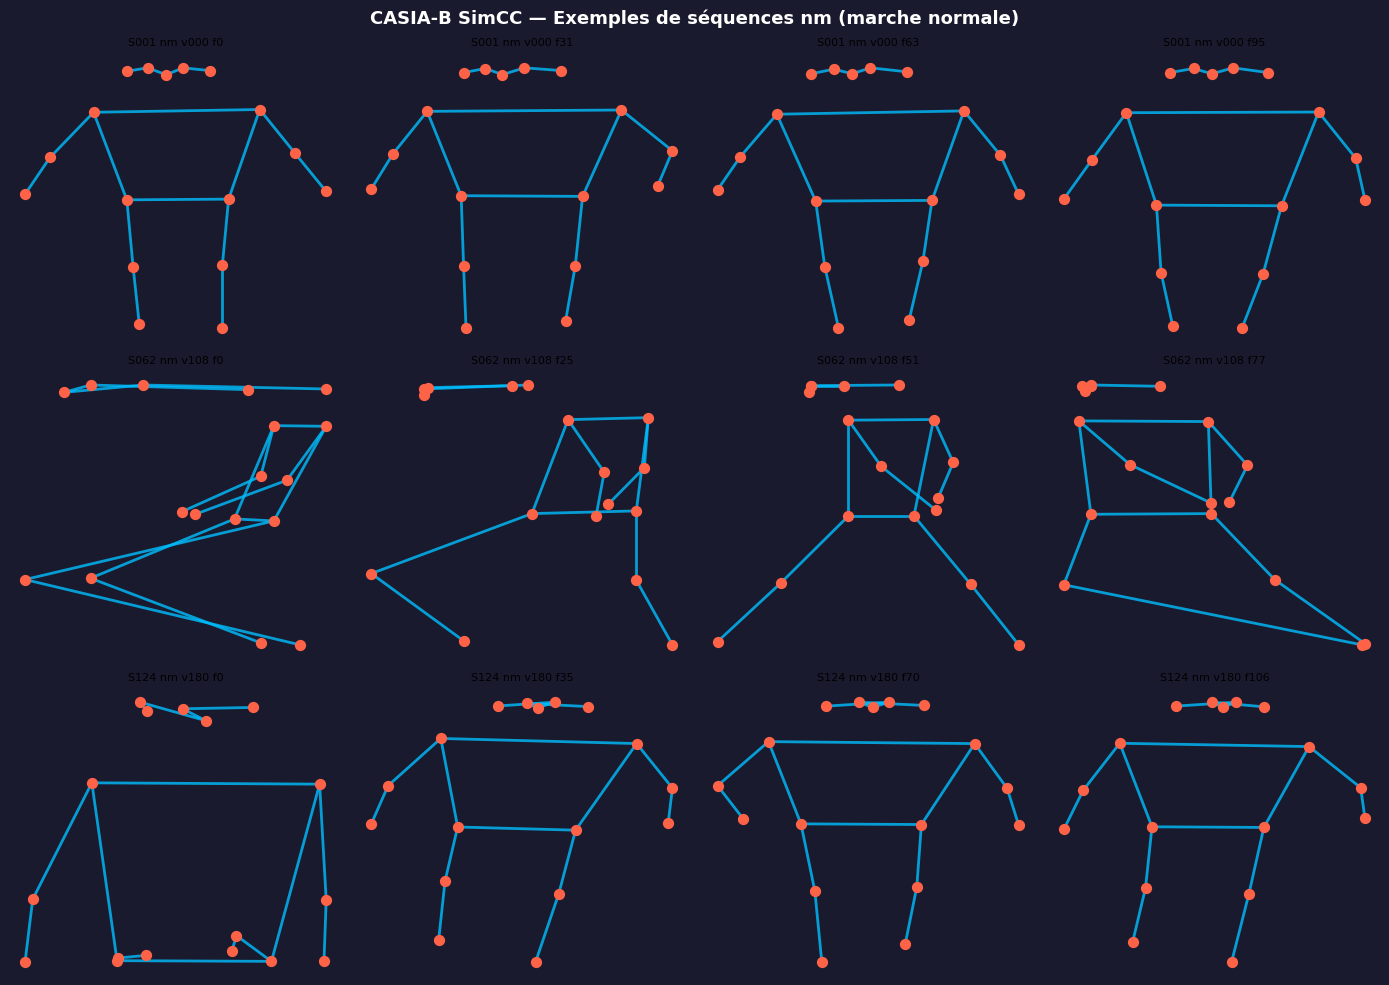


📊 Résumé dataset :
  Séquences totales : 8175
  Frames par séquence : min=25, max=307, moy=101


In [6]:
# ============================================================
# CELL 3 — Visualiser quelques séquences
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def draw_skeleton(ax, kp, color_bone='royalblue', color_joint='tomato', title=''):
    """
    kp : (17, 2) ou (17, 3) — on prend x,y seulement
    """
    xy = kp[:, :2]
    ax.invert_yaxis()

    for i, j in SKELETON_PAIRS:
        ax.plot([xy[i,0], xy[j,0]],
                [xy[i,1], xy[j,1]],
                color=color_bone, lw=2, alpha=0.8)

    ax.scatter(xy[:,0], xy[:,1], c=color_joint, s=50, zorder=5)
    ax.set_title(title, fontsize=8)
    ax.axis('off')


# Choisir 3 séquences variées
sample_indices = [0, len(sequences)//2, -1]

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
fig.patch.set_facecolor('#1a1a2e')

for row, idx in enumerate(sample_indices):
    seq  = sequences[idx]
    meta = metadata[idx]

    # 4 frames réparties sur la séquence
    frame_ids = np.linspace(0, len(seq)-1, 4, dtype=int)

    for col, fi in enumerate(frame_ids):
        ax = axes[row][col]
        ax.set_facecolor('#1a1a2e')
        draw_skeleton(ax, seq[fi],
                      title=f"S{meta['subject']} {meta['condition']} "
                            f"v{meta['view']} f{fi}",
                      color_bone='deepskyblue',
                      color_joint='tomato')

plt.suptitle("CASIA-B SimCC — Exemples de séquences nm (marche normale)",
             color='white', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n📊 Résumé dataset :")
print(f"  Séquences totales : {len(sequences)}")
print(f"  Frames par séquence : min={min(m['frames'] for m in metadata)}, "
      f"max={max(m['frames'] for m in metadata)}, "
      f"moy={np.mean([m['frames'] for m in metadata]):.0f}")

In [7]:
# ============================================================
# CELL 4 — Feature extraction & sliding windows
#
# POURQUOI cette normalisation ?
# Les coordonnées brutes dépendent de la résolution vidéo.
# Pour que le modèle apprenne des PATTERNS DE MOUVEMENT
# (et non des positions absolues), on normalise :
#   1. Centrage sur la hanche (point stable du corps)
#   2. Mise à l'échelle par la hauteur du torse
# ============================================================

WINDOW_SIZE   = 30   # 30 frames passées → input du LSTM
                     # ~500ms à ~16fps → cohérent avec l'article
PREDICT_STEPS = 8    # 8 frames futures à prédire
                     # ~500ms anticipation (objectif du papier)
STRIDE        = 5    # pas entre fenêtres (évite trop de redondance)
FPS           = 16   # fps estimé CASIA-B

def extract_features(kp_seq):
    """
    Input  : (T, 17, 3)  — coordonnées brutes
    Output : (T, 34)     — features normalisées (x,y relatif × 17)

    Normalisation :
    - Centre = milieu des deux hanches (keypoints 11 et 12)
    - Echelle = distance nez-hanche (hauteur torse approximative)
    """
    xy   = kp_seq[:, :, :2].copy().astype(np.float32)  # (T, 17, 2)

    # Centre = milieu hanches gauche(11) + droite(12)
    hip_center = (xy[:, 11, :] + xy[:, 12, :]) / 2.0   # (T, 2)

    # Coordonnées relatives au centre
    rel = xy - hip_center[:, np.newaxis, :]              # (T, 17, 2)

    # Echelle = distance nez(0) → hanche
    torso_h = np.linalg.norm(xy[:, 0, :] - hip_center, axis=1)  # (T,)
    torso_h = np.maximum(torso_h, 1e-6)                           # évite /0

    # Normalisation
    rel = rel / torso_h[:, np.newaxis, np.newaxis]

    return rel.reshape(len(kp_seq), -1)  # (T, 34)


def build_windows(sequences, window_size=WINDOW_SIZE,
                  predict_steps=PREDICT_STEPS, stride=STRIDE):
    """
    Construit les paires (X, Y) :
    X : fenêtre de WINDOW_SIZE frames passées → input LSTM
    Y : PREDICT_STEPS frames futures          → ce qu'on veut prédire

    Pour chaque séquence de longueur T :
    On glisse une fenêtre et on crée autant d'exemples que possible.
    """
    X_list, Y_list, meta_list = [], [], []

    for i, seq in enumerate(tqdm(sequences, desc="Building windows")):
        feats = extract_features(seq)  # (T, 34)
        T = len(feats)

        min_len = window_size + predict_steps
        if T < min_len:
            continue

        for start in range(0, T - min_len + 1, stride):
            end_x  = start + window_size
            end_y  = end_x  + predict_steps

            X_list.append(feats[start : end_x])   # (30, 34)
            Y_list.append(feats[end_x : end_y])   # ( 8, 34)
            meta_list.append({
                'seq_idx'  : i,
                'start'    : start,
                'subject'  : metadata[i]['subject'],
                'condition': metadata[i]['condition'],
            })

    X = np.array(X_list, dtype=np.float32)
    Y = np.array(Y_list, dtype=np.float32)

    print(f"\n✅ Fenêtres créées :")
    print(f"   X shape : {X.shape}  →  (N, {window_size} frames, 34 features)")
    print(f"   Y shape : {Y.shape}  →  (N, {predict_steps} frames, 34 features)")
    print(f"   Mémoire : {X.nbytes/1e6:.1f} MB + {Y.nbytes/1e6:.1f} MB")
    print(f"\n   Interprétation :")
    print(f"   → Le LSTM voit {window_size} frames = "
          f"{window_size*1000//FPS}ms de marche passée")
    print(f"   → Il prédit {predict_steps} frames = "
          f"{predict_steps*1000//FPS}ms dans le futur")

    return X, Y, meta_list


X, Y, win_meta = build_windows(sequences)

Building windows: 100%|██████████| 8175/8175 [00:00<00:00, 10070.76it/s]



✅ Fenêtres créées :
   X shape : (107489, 30, 34)  →  (N, 30 frames, 34 features)
   Y shape : (107489, 8, 34)  →  (N, 8 frames, 34 features)
   Mémoire : 438.6 MB + 116.9 MB

   Interprétation :
   → Le LSTM voit 30 frames = 1875ms de marche passée
   → Il prédit 8 frames = 500ms dans le futur


In [8]:
# ============================================================
# CELL 5 — Architecture LSTM Anticipator
#
# Basé sur arXiv:2509.05337
# Input  : (batch, 30, 34)  → 30 frames de marche passée
# Output : (batch, 8,  34)  → 8 frames futures prédites
# ============================================================

class LSTMAnticipator(nn.Module):
    def __init__(self,
                 input_size    = 34,
                 hidden_size   = 256,
                 num_layers    = 2,
                 predict_steps = PREDICT_STEPS,
                 dropout       = 0.3):
        super().__init__()

        self.predict_steps = predict_steps
        self.input_size    = input_size

        # Encodeur LSTM bidirectionnel
        # Bidirectionnel = le réseau comprend mieux les patterns
        # de mouvement en les lisant dans les 2 sens
        self.lstm = nn.LSTM(
            input_size  = input_size,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            batch_first = True,
            dropout     = dropout if num_layers > 1 else 0,
            bidirectional = False   # unidirectionnel pour la prédiction
        )

        self.dropout = nn.Dropout(dropout)

        # Tête de prédiction : dernier état caché → poses futures
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, input_size * predict_steps)
        )

        # Initialisation (même que l'article)
        self._init_weights()

    def _init_weights(self):
        for name, p in self.named_parameters():
            if 'weight_ih' in name:
                nn.init.xavier_uniform_(p)
            elif 'weight_hh' in name:
                nn.init.orthogonal_(p)
            elif 'bias' in name:
                nn.init.zeros_(p)
        # FC layers
        for m in self.fc.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        # x : (B, T, 34)
        out, _ = self.lstm(x)                 # (B, T, 256)
        last   = self.dropout(out[:, -1, :])  # (B, 256) — dernier pas de temps
        pred   = self.fc(last)                # (B, 8*34)
        return pred.view(x.size(0), self.predict_steps, self.input_size)


# Instanciation
model = LSTMAnticipator(
    input_size    = 34,
    hidden_size   = 256,
    num_layers    = 2,
    predict_steps = PREDICT_STEPS,
    dropout       = 0.3
).to(device)

# Résumé
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✅ LSTM Anticipator prêt")
print(f"   Paramètres  : {n_params:,}")
print(f"   Input       : (batch, {WINDOW_SIZE}, 34)")
print(f"   Output      : (batch, {PREDICT_STEPS}, 34)")
print(f"   Anticipation: {PREDICT_STEPS*1000//FPS} ms dans le futur")

# Test rapide
dummy = torch.zeros(4, WINDOW_SIZE, 34).to(device)
out   = model(dummy)
print(f"   Test forward: {dummy.shape} → {out.shape} ✓")

✅ LSTM Anticipator prêt
   Paramètres  : 961,040
   Input       : (batch, 30, 34)
   Output      : (batch, 8, 34)
   Anticipation: 500 ms dans le futur
   Test forward: torch.Size([4, 30, 34]) → torch.Size([4, 8, 34]) ✓


Train : 85,992 fenêtres | Val : 21,497 fenêtres

🚀 Entraînement sur 80 epochs...

  Epoch 001/80 | Train: 0.04426 | Val: 0.03253 | Best: 0.03253 | LR: 1.00e-03 ⭐
  Epoch 010/80 | Train: 0.02837 | Val: 0.03095 | Best: 0.03083 | LR: 1.00e-03 
  Epoch 020/80 | Train: 0.02822 | Val: 0.03093 | Best: 0.03079 | LR: 1.00e-03 
  Epoch 030/80 | Train: 0.02806 | Val: 0.03087 | Best: 0.03073 | LR: 5.00e-04 
  Epoch 040/80 | Train: 0.02802 | Val: 0.03113 | Best: 0.03063 | LR: 5.00e-04 
  Epoch 050/80 | Train: 0.02773 | Val: 0.03041 | Best: 0.03037 | LR: 5.00e-04 
  Epoch 060/80 | Train: 0.02763 | Val: 0.03028 | Best: 0.03028 | LR: 2.50e-04 ⭐
  Epoch 070/80 | Train: 0.02764 | Val: 0.03026 | Best: 0.03022 | LR: 1.25e-04 
  Epoch 080/80 | Train: 0.02752 | Val: 0.03025 | Best: 0.03018 | LR: 6.25e-05 


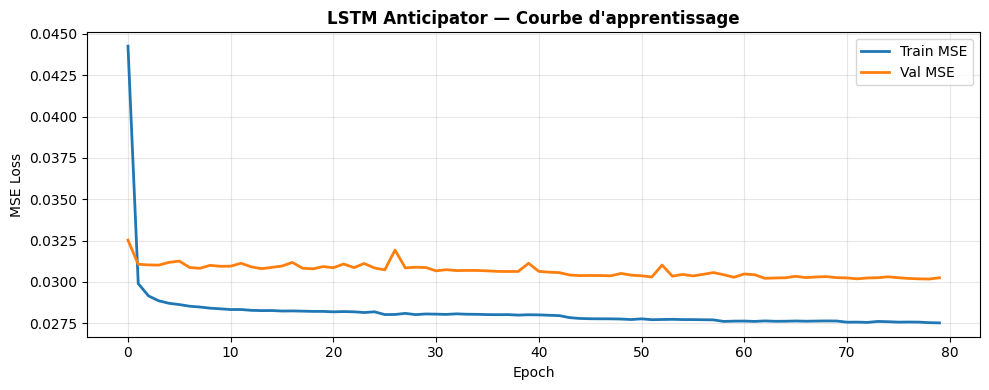


✅ Meilleur Val MSE : 0.030176
💾 Modèle sauvegardé : /content/lstm_anticipator_best.pth


In [9]:
# ============================================================
# CELL 6 — Training
# ============================================================
from torch.utils.data import Dataset, DataLoader, random_split

class GaitDataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.from_numpy(X)
        self.Y = torch.from_numpy(Y)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, i):
        return self.X[i], self.Y[i]


# --- Split train/val (par fenêtres, pas par sujets — OK pour pré-entraînement) ---
n_total = len(X)
n_val   = int(0.2 * n_total)
n_tr    = n_total - n_val

dataset  = GaitDataset(X, Y)
tr_set, val_set = random_split(dataset, [n_tr, n_val],
                               generator=torch.Generator().manual_seed(SEED))

tr_loader  = DataLoader(tr_set,  batch_size=256, shuffle=True,
                        num_workers=2, pin_memory=True)
val_loader = DataLoader(val_set, batch_size=256, shuffle=False,
                        num_workers=2, pin_memory=True)

print(f"Train : {n_tr:,} fenêtres | Val : {n_val:,} fenêtres")

# --- Optimizer & Scheduler ---
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=5, factor=0.5)

EPOCHS    = 80
best_val  = float('inf')
tr_hist   = []
val_hist  = []

print(f"\n🚀 Entraînement sur {EPOCHS} epochs...\n")

for epoch in range(1, EPOCHS + 1):

    # ---- Train ----
    model.train()
    tr_loss = 0.0
    for xb, yb in tr_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        tr_loss += loss.item()

    # ---- Validate ----
    model.eval()
    vl_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            vl_loss += criterion(model(xb), yb).item()

    tr_loss /= len(tr_loader)
    vl_loss /= len(val_loader)
    tr_hist.append(tr_loss)
    val_hist.append(vl_loss)
    scheduler.step(vl_loss)

    # Sauvegarde meilleur modèle
    is_best = vl_loss < best_val
    if is_best:
        best_val = vl_loss
        torch.save(model.state_dict(), '/content/lstm_anticipator_best.pth')

    if epoch % 10 == 0 or epoch == 1:
        current_lr = optimizer.param_groups[0]['lr']
        print(f"  Epoch {epoch:03d}/{EPOCHS} | "
              f"Train: {tr_loss:.5f} | "
              f"Val: {vl_loss:.5f} | "
              f"Best: {best_val:.5f} | "
              f"LR: {current_lr:.2e} "
              f"{'⭐' if is_best else ''}")

# --- Courbe d'apprentissage ---
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(tr_hist,  label='Train MSE', lw=2)
ax.plot(val_hist, label='Val MSE',   lw=2)
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE Loss')
ax.set_title('LSTM Anticipator — Courbe d\'apprentissage', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(f"\n✅ Meilleur Val MSE : {best_val:.6f}")
print(f"💾 Modèle sauvegardé : /content/lstm_anticipator_best.pth")

📊 MSE par pas de prédiction :
  t+ 62ms  MSE=0.00065  ███
  t+125ms  MSE=0.00081  ████
  t+187ms  MSE=0.00088  ████
  t+250ms  MSE=0.00110  █████
  t+312ms  MSE=0.00140  ██████
  t+375ms  MSE=0.00155  ███████
  t+437ms  MSE=0.00205  ██████████
  t+500ms  MSE=0.00254  ████████████


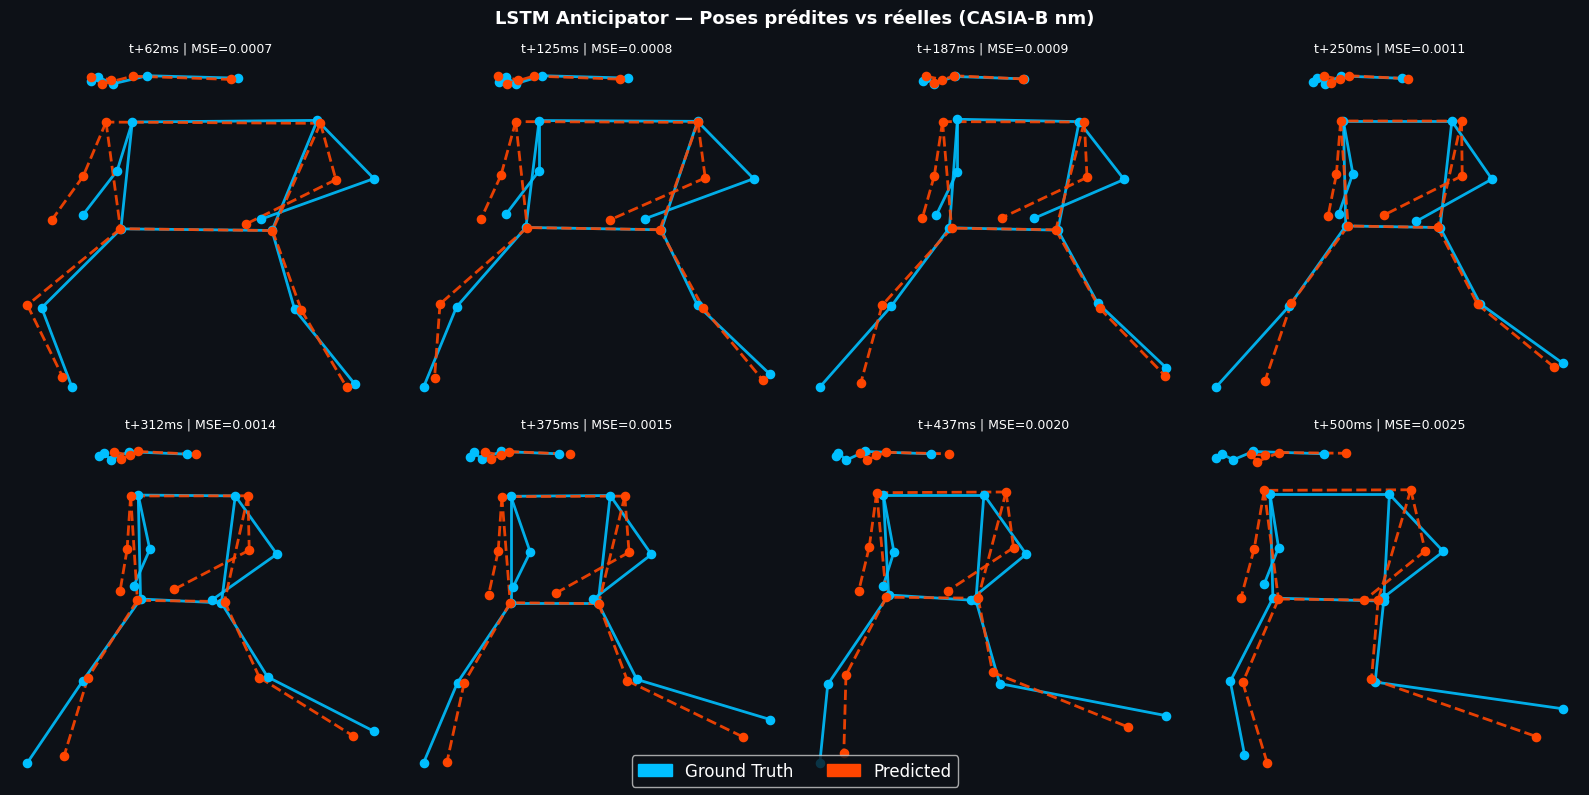

In [10]:
# CELL 7 — Visualisation : Poses prédites vs réelles
model.load_state_dict(torch.load('/content/lstm_anticipator_best.pth'))
model.eval()

# Prendre 1 sample de validation
x_samp = dataset[n_tr][0].unsqueeze(0).to(device)  # (1, 30, 34)
y_true = dataset[n_tr][1].numpy()                   # (8, 34)

with torch.no_grad():
    y_pred = model(x_samp).cpu().numpy()[0]          # (8, 34)

# MSE par step
step_mse = [np.mean((y_pred[s] - y_true[s])**2)
            for s in range(PREDICT_STEPS)]

print("📊 MSE par pas de prédiction :")
for s, mse in enumerate(step_mse):
    ms = (s + 1) * 1000 // FPS
    bar = '█' * int(mse * 5000)
    print(f"  t+{ms:3d}ms  MSE={mse:.5f}  {bar}")

# --- Visualisation squelettes ---
def flat2kp(arr):
    """(34,) → (17, 2)"""
    return arr.reshape(17, 2)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.patch.set_facecolor('#0d1117')

for step in range(PREDICT_STEPS):
    ax  = axes[step // 4][step % 4]
    ax.set_facecolor('#0d1117')
    ax.invert_yaxis()

    gt = flat2kp(y_true[step])
    pr = flat2kp(y_pred[step])

    # Ground truth (bleu)
    for i, j in SKELETON_PAIRS:
        ax.plot([gt[i,0], gt[j,0]], [gt[i,1], gt[j,1]],
                color='deepskyblue', lw=2, alpha=0.9)
    ax.scatter(gt[:,0], gt[:,1], c='deepskyblue', s=35, zorder=5)

    # Prédiction (rouge pointillé)
    for i, j in SKELETON_PAIRS:
        ax.plot([pr[i,0], pr[j,0]], [pr[i,1], pr[j,1]],
                color='orangered', lw=2, alpha=0.9, linestyle='--')
    ax.scatter(pr[:,0], pr[:,1], c='orangered', s=35, zorder=5)

    ms = (step + 1) * 1000 // FPS
    ax.set_title(f"t+{ms}ms | MSE={step_mse[step]:.4f}",
                 color='white', fontsize=9)
    ax.axis('off')

handles = [
    mpatches.Patch(color='deepskyblue', label='Ground Truth'),
    mpatches.Patch(color='orangered',   label='Predicted')
]
fig.legend(handles=handles, loc='lower center', ncol=2,
           fontsize=12, facecolor='#0d1117', labelcolor='white')
fig.suptitle("LSTM Anticipator — Poses prédites vs réelles (CASIA-B nm)",
             color='white', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [11]:
# ============================================================
# CELL 8 — Download + Inspect URFD
# ============================================================
import kagglehub, pickle, numpy as np, os
from pathlib import Path
from collections import Counter

# Download
urfd_path_raw = kagglehub.dataset_download("mireillejabbour/fall-dataset")
URFD_ROOT = Path(urfd_path_raw)
print(f"✅ URFD path: {URFD_ROOT}\n")

# Structure
print("=== FOLDER STRUCTURE (4 levels) ===")
for root, dirs, files_ in os.walk(URFD_ROOT):
    level = str(root).replace(str(URFD_ROOT), '').count(os.sep)
    if level > 4: continue
    indent = '  ' * level
    print(f"{indent}{os.path.basename(root)}/")
    for f in sorted(files_)[:5]:
        size = os.path.getsize(os.path.join(root, f)) / 1024
        print(f"{indent}  📄 {f}  ({size:.1f} KB)")

# File types
all_files = [f for f in URFD_ROOT.rglob('*') if f.is_file()]
exts = Counter(f.suffix.lower() for f in all_files)
print(f"\n=== FILE TYPES ===")
print(f"Total : {len(all_files)}")
for ext, n in exts.most_common():
    print(f"  {ext if ext else 'no_ext'} : {n}")

# Peek first 3 files
print("\n=== PEEK FIRST 3 FILES ===")
for fp in all_files[:3]:
    ext = fp.suffix.lower()
    size = fp.stat().st_size / 1024
    print(f"\n📄 {fp.name}  ({size:.1f} KB)")
    print(f"   Path: {fp}")
    try:
        if ext == '.pkl':
            with open(fp, 'rb') as f: d = pickle.load(f)
            if isinstance(d, np.ndarray):
                print(f"   → ndarray  shape={d.shape}  dtype={d.dtype}")
                print(f"   → min={d.min():.3f}  max={d.max():.3f}")
            elif isinstance(d, dict):
                print(f"   → dict  keys={list(d.keys())[:8]}")
            elif isinstance(d, list):
                print(f"   → list  len={len(d)}")
                if hasattr(d[0], 'shape'): print(f"   → elem shape={d[0].shape}")
        elif ext == '.npy':
            d = np.load(fp, allow_pickle=True)
            print(f"   → npy  shape={d.shape}  dtype={d.dtype}")
        elif ext == '.npz':
            d = np.load(fp, allow_pickle=True)
            print(f"   → npz  keys={list(d.keys())}")
            for k in list(d.keys())[:3]:
                print(f"      '{k}': {d[k].shape}")
        elif ext == '.csv':
            import pandas as pd
            df = pd.read_csv(fp, nrows=3)
            print(f"   → csv  shape={df.shape}  cols={list(df.columns[:8])}")
        elif ext in ['.mp4', '.avi']:
            print(f"   → VIDEO FILE (raw video, no keypoints extracted yet)")
        elif ext in ['.txt', '.json']:
            with open(fp) as f: content = f.read(300)
            print(f"   → content preview: {content[:200]}")
    except Exception as e:
        print(f"   ❌ {e}")

100%|██████████| 8.05G/8.05G [01:38<00:00, 87.4MB/s]

Extracting files...


✅ URFD path: /root/.cache/kagglehub/datasets/mireillejabbour/fall-dataset/versions/2

=== FOLDER STRUCTURE (4 levels) ===
2/
  fall zip photo files/
    fall zip photo files/
      fall-14-cam0-d/
        fall-14-cam0-d/
          📄 fall-14-cam0-d-001.png  (262.0 KB)
          📄 fall-14-cam0-d-002.png  (254.5 KB)
          📄 fall-14-cam0-d-003.png  (258.3 KB)
          📄 fall-14-cam0-d-004.png  (259.7 KB)
          📄 fall-14-cam0-d-005.png  (262.5 KB)
      fall-12-cam0-rgb/
        fall-12-cam0-rgb/
          📄 fall-12-cam0-rgb-001.png  (357.6 KB)
          📄 fall-12-cam0-rgb-002.png  (357.1 KB)
          📄 fall-12-cam0-rgb-003.png  (356.6 KB)
          📄 fall-12-cam0-rgb-004.png  (356.3 KB)
          📄 fall-12-cam0-rgb-005.png  (356.2 KB)
      fall-06-cam1-rgb/
        fall-06-cam1-rgb/
          📄 fall-06-cam1-rgb-001.png  (379.9 KB)
          📄 fall-06-cam1-rgb-002.png  (379.1 KB)
          📄 fall-06-cam1-rgb-003.png  (378.6 KB)
          📄 fall-06-cam1-rgb-004.png  (378.1 KB)
   

In [12]:
# ============================================================
# CELLULE A — Fix NumPy + MediaPipe (LANCER SEULE)
# ============================================================
#!pip install numpy==1.26.4 --force-reinstall -q
!pip install mediapipe==0.10.14 -q   # version la plus stable avec numpy 1.26

# ⚠️ OBLIGATOIRE : redémarre le kernel après cette cellule
# Runtime → Restart session (ou Ctrl+M .)
print("✅ Installation terminée — REDÉMARRE LE KERNEL MAINTENANT")
print("   Runtime → Restart session")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.7/35.7 MB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 30.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 4.25.8 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 4.25.8 which is incompatible.
grain 0.2.16 requires protobuf>=5.28.3, but you have protobuf 4.25.8 which is incompatible.
opentelemetry-proto 1.38.0 requires protobuf<7.0,>=5.0, but you have protobuf 4.25.8 which is incompatible.
✅ Installation terminée — REDÉMARRE LE KERNEL MAINTENANT
   Runtime → Restart session


In [13]:
# ============================================================
# CELL DIAGNOSTIC — Voir la structure exacte des ADLs
# ============================================================
from pathlib import Path

URFD_ROOT = Path(urfd_path_raw)
adl_root  = URFD_ROOT / "adl zip photo files" / "adl zip photo files"

all_adl_dirs = sorted([d for d in adl_root.iterdir() if d.is_dir()])
print(f"Total dossiers ADL : {len(all_adl_dirs)}")
print("\nListe complète :")
for d in all_adl_dirs:
    print(f"  {d.name}")

Total dossiers ADL : 80

Liste complète :
  adl-01-cam0-d
  adl-01-cam0-rgb
  adl-02-cam0-d
  adl-02-cam0-rgb
  adl-03-cam0-d
  adl-03-cam0-rgb
  adl-04-cam0-d
  adl-04-cam0-rgb
  adl-05-cam0-d
  adl-05-cam0-rgb
  adl-06-cam0-d
  adl-06-cam0-rgb
  adl-07-cam0-d
  adl-07-cam0-rgb
  adl-08-cam0-d
  adl-08-cam0-rgb
  adl-09-cam0-d
  adl-09-cam0-rgb
  adl-10-cam0-d
  adl-10-cam0-rgb
  adl-11-cam0-d
  adl-11-cam0-rgb
  adl-12-cam0-d
  adl-12-cam0-rgb
  adl-13-cam0-d
  adl-13-cam0-rgb
  adl-14-cam0-d
  adl-14-cam0-rgb
  adl-15-cam0-d
  adl-15-cam0-rgb
  adl-16-cam0-d
  adl-16-cam0-rgb
  adl-17-cam0-d
  adl-17-cam0-rgb
  adl-18-cam0-d
  adl-18-cam0-rgb
  adl-19-cam0-d
  adl-19-cam0-rgb
  adl-20-cam0-d
  adl-20-cam0-rgb
  adl-21-cam0-d
  adl-21-cam0-rgb
  adl-22-cam0-d
  adl-22-cam0-rgb
  adl-23-cam0-d
  adl-23-cam0-rgb
  adl-24-cam0-d
  adl-24-cam0-rgb
  adl-25-cam0-d
  adl-25-cam0-rgb
  adl-26-cam0-d
  adl-26-cam0-rgb
  adl-27-cam0-d
  adl-27-cam0-rgb
  adl-28-cam0-d
  adl-28-cam0-rgb
  adl-

In [14]:
# ============================================================
# CELL 9 — Extract keypoints from URFD using MediaPipe Pose
# ALL VIEWS (120 fall sequences) + ALL ADLs (depth inclus)
# ============================================================
import os, cv2, numpy as np, pickle
import mediapipe as mp
from pathlib import Path
from tqdm import tqdm

print(f"✅ NumPy     version : {np.__version__}")
print(f"✅ MediaPipe version : {mp.__version__}")

# ── Config ──────────────────────────────────────────────────
URFD_ROOT = Path(urfd_path_raw)
SAVE_PATH = Path("/content/urfd_keypoints")
SAVE_PATH.mkdir(exist_ok=True)

# MP → COCO-17 mapping
MP_INDICES = [0, 2, 1, 4, 3, 6, 5, 8, 7, 10, 9, 12, 11, 14, 13, 16, 15]

# ── Init MediaPipe nouvelle API ──────────────────────────────
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import urllib.request

MODEL_PATH = "/content/pose_landmarker_heavy.task"
if not os.path.exists(MODEL_PATH):
    print("⏳ Téléchargement pose_landmarker_heavy.task (~30MB)...")
    urllib.request.urlretrieve(
        "https://storage.googleapis.com/mediapipe-models/pose_landmarker/"
        "pose_landmarker_heavy/float16/latest/pose_landmarker_heavy.task",
        MODEL_PATH
    )
    print("✅ Modèle téléchargé")
else:
    print("✅ Modèle déjà présent")

base_options = python.BaseOptions(model_asset_path=MODEL_PATH)
options = vision.PoseLandmarkerOptions(
    base_options=base_options,
    output_segmentation_masks=False,
    num_poses=1,
    min_pose_detection_confidence=0.1,
    min_pose_presence_confidence=0.1,
    min_tracking_confidence=0.1,
    running_mode=vision.RunningMode.IMAGE
)
pose = vision.PoseLandmarker.create_from_options(options)
print("✅ PoseLandmarker initialisé\n")


# ── Fonctions ────────────────────────────────────────────────
def extract_keypoints_mediapipe(img_path):
    """
    Lit une image et retourne (17, 3) ordre COCO-17
    (x_pixel, y_pixel, visibility)
    Retourne None si pas de détection
    """
    img = cv2.imread(str(img_path))
    if img is None:
        return None

    img_rgb  = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w     = img_rgb.shape[:2]
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=img_rgb)
    results  = pose.detect(mp_image)

    if not results.pose_landmarks or len(results.pose_landmarks) == 0:
        return None

    lm = results.pose_landmarks[0]
    kp = np.zeros((17, 3), dtype=np.float32)
    for coco_idx, mp_idx in enumerate(MP_INDICES):
        kp[coco_idx, 0] = lm[mp_idx].x * w
        kp[coco_idx, 1] = lm[mp_idx].y * h
        kp[coco_idx, 2] = getattr(lm[mp_idx], 'visibility', 1.0)
    return kp


def process_sequence(seq_dir, min_frames=5, min_rate=0.5):
    """
    Traite tous les PNG d'un dossier → (T, 17, 3)
    Retourne None si taux de détection insuffisant
    """
    frames = sorted(seq_dir.glob("*.png"))
    if len(frames) == 0:
        return None

    keypoints = []
    for fp in frames:
        kp = extract_keypoints_mediapipe(fp)
        if kp is not None:
            keypoints.append(kp)

    detection_rate = len(keypoints) / max(len(frames), 1)
    if len(keypoints) < min_frames or detection_rate < min_rate:
        return None

    return np.stack(keypoints, axis=0)   # (T, 17, 3)


def get_actual_dir(seq_dir):
    """Gère la double imbrication de dossiers dans URFD"""
    inner = [d for d in seq_dir.iterdir() if d.is_dir()]
    return inner[0] if len(inner) == 1 else seq_dir


# ── Process FALLS — TOUTES LES VUES (cam0+cam1, rgb+depth) ──
print("=" * 55)
print("📂 Processing FALL sequences — TOUTES VUES")
print("=" * 55)
fall_root = URFD_ROOT / "fall zip photo files" / "fall zip photo files"

fall_dirs = sorted([d for d in fall_root.iterdir() if d.is_dir()])
print(f"  Séquences trouvées : {len(fall_dirs)}")
print(f"  (30 chutes × 4 vues = cam0-d, cam0-rgb, cam1-d, cam1-rgb)\n")

fall_sequences = {}
skipped_falls  = []

for seq_dir in tqdm(fall_dirs, desc="Falls"):
    actual_dir = get_actual_dir(seq_dir)
    kp_seq     = process_sequence(actual_dir)
    if kp_seq is not None:
        fall_sequences[seq_dir.name] = kp_seq
    else:
        skipped_falls.append(seq_dir.name)

print(f"\n  ✅ Falls traitées  : {len(fall_sequences)}/{len(fall_dirs)}")
if skipped_falls:
    print(f"  ⚠️  Skipped ({len(skipped_falls)}) : {', '.join(skipped_falls)}")


# ── Process ADLs — TOUTES LES VUES (depth inclus) ────────────
print("\n" + "=" * 55)
print("📂 Processing ADL sequences — TOUTES VUES (depth inclus)")
print("=" * 55)
adl_root = URFD_ROOT / "adl zip photo files" / "adl zip photo files"

# Toutes les vues ADL sans aucun filtre
adl_dirs = sorted([d for d in adl_root.iterdir() if d.is_dir()])
print(f"  Séquences trouvées : {len(adl_dirs)}\n")

adl_sequences = {}
skipped_adls  = []

for seq_dir in tqdm(adl_dirs, desc="ADLs"):
    actual_dir = get_actual_dir(seq_dir)
    kp_seq     = process_sequence(actual_dir)
    if kp_seq is not None:
        adl_sequences[seq_dir.name] = kp_seq
    else:
        skipped_adls.append(seq_dir.name)

print(f"\n  ✅ ADLs traitées   : {len(adl_sequences)}/{len(adl_dirs)}")
if skipped_adls:
    print(f"  ⚠️  Skipped ({len(skipped_adls)}) : {', '.join(skipped_adls)}")


# ── Sauvegarde ───────────────────────────────────────────────
print("\n💾 Sauvegarde...")
with open(SAVE_PATH / "fall_keypoints.pkl", 'wb') as f:
    pickle.dump(fall_sequences, f)
with open(SAVE_PATH / "adl_keypoints.pkl", 'wb') as f:
    pickle.dump(adl_sequences, f)
print("  ✅ fall_keypoints.pkl")
print("  ✅ adl_keypoints.pkl")


# ── Résumé final ─────────────────────────────────────────────
all_fall_len = [v.shape[0] for v in fall_sequences.values()]
all_adl_len  = [v.shape[0] for v in adl_sequences.values()]

print(f"\n{'='*55}")
print(f"✅  URFD Keypoints Extraction — COMPLETE")
print(f"{'='*55}")
print(f"  Fall sequences  : {len(fall_sequences)}")
print(f"  ADL  sequences  : {len(adl_sequences)}")
if all_fall_len:
    print(f"  Fall frames     : min={min(all_fall_len)} | "
          f"max={max(all_fall_len)} | "
          f"mean={np.mean(all_fall_len):.1f} | "
          f"total={sum(all_fall_len)}")
if all_adl_len:
    print(f"  ADL  frames     : min={min(all_adl_len)} | "
          f"max={max(all_adl_len)} | "
          f"mean={np.mean(all_adl_len):.1f} | "
          f"total={sum(all_adl_len)}")
print(f"  Format          : (T, 17, 3) COCO-17 ✅ compatible CASIA-B")
print(f"  Sauvegardé dans : {SAVE_PATH}")
print(f"{'='*55}")

✅ NumPy     version : 2.0.2
✅ MediaPipe version : 0.10.14
⏳ Téléchargement pose_landmarker_heavy.task (~30MB)...
✅ Modèle téléchargé
✅ PoseLandmarker initialisé

📂 Processing FALL sequences — TOUTES VUES
  Séquences trouvées : 118
  (30 chutes × 4 vues = cam0-d, cam0-rgb, cam1-d, cam1-rgb)



Falls:   0%|          | 0/118 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '
Falls: 100%|██████████| 118/118 [20:17<00:00, 10.31s/it]



  ✅ Falls traitées  : 110/118
  ⚠️  Skipped (8) : fall-13-cam1-rgb, fall-15-cam1-rgb, fall-17-cam1-rgb, fall-21-cam1-rgb, fall-23-cam1-rgb, fall-25-cam1-rgb, fall-27-cam1-rgb, fall-29-cam1-rgb

📂 Processing ADL sequences — TOUTES VUES (depth inclus)
  Séquences trouvées : 80



ADLs: 100%|██████████| 80/80 [25:56<00:00, 19.46s/it]


  ✅ ADLs traitées   : 66/80
  ⚠️  Skipped (14) : adl-10-cam0-d, adl-11-cam0-d, adl-19-cam0-rgb, adl-28-cam0-d, adl-29-cam0-d, adl-30-cam0-d, adl-31-cam0-d, adl-33-cam0-d, adl-34-cam0-d, adl-36-cam0-d, adl-37-cam0-d, adl-38-cam0-d, adl-39-cam0-d, adl-40-cam0-d

💾 Sauvegarde...
  ✅ fall_keypoints.pkl
  ✅ adl_keypoints.pkl

✅  URFD Keypoints Extraction — COMPLETE
  Fall sequences  : 110
  ADL  sequences  : 66
  Fall frames     : min=40 | max=212 | mean=89.5 | total=9844
  ADL  frames     : min=51 | max=309 | mean=164.5 | total=10854
  Format          : (T, 17, 3) COCO-17 ✅ compatible CASIA-B
  Sauvegardé dans : /content/urfd_keypoints


In [15]:
# ============================================================
# CELL 10 (v4) — Labellisation URFD only, sans augmentation
# ============================================================
import numpy as np, pickle
from pathlib import Path
from collections import Counter

SAVE_PATH = Path("/content/urfd_keypoints")

with open(SAVE_PATH / "fall_keypoints.pkl", 'rb') as f:
    fall_sequences = pickle.load(f)
with open(SAVE_PATH / "adl_keypoints.pkl", 'rb') as f:
    adl_sequences = pickle.load(f)

# ── Paramètres ───────────────────────────────────────────────
FPS        = 30
PRE_FALL_F = 20   # 667ms
FALL_F     = 15   # 500ms

print(f"Fall sequences  : {len(fall_sequences)}")
print(f"ADL  sequences  : {len(adl_sequences)}")
print(f"PRE_FALL = {PRE_FALL_F} frames ({1000*PRE_FALL_F//FPS}ms)")
print(f"FALL     = {FALL_F} frames ({1000*FALL_F//FPS}ms)")

def label_fall_sequence(T):
    labels        = np.zeros(T, dtype=np.int64)
    fall_start    = max(0, T - FALL_F)
    prefall_start = max(0, T - FALL_F - PRE_FALL_F)
    labels[prefall_start:fall_start] = 1
    labels[fall_start:]              = 2
    return labels

# ── Construction dataset URFD — NO augmentation ──────────────
labeled_data = []

# FALLS — séquences originales uniquement
print("\n📂 Adding FALL sequences (originales, sans augmentation)...")
for name, kp in fall_sequences.items():
    T      = kp.shape[0]
    labels = label_fall_sequence(T)
    labeled_data.append({
        'keypoints': kp,
        'labels':    labels,
        'name':      name,
        'is_fall':   True
    })
print(f"  → {len(fall_sequences)} séquences de chutes")

# ADLs — séquences originales uniquement
print("\n📂 Adding ADL sequences (originales, sans augmentation)...")
for name, kp in adl_sequences.items():
    T = kp.shape[0]
    labeled_data.append({
        'keypoints': kp,
        'labels':    np.zeros(T, dtype=np.int64),
        'name':      name,
        'is_fall':   False
    })
print(f"  → {len(adl_sequences)} séquences ADL")

# ── Stats ─────────────────────────────────────────────────────
all_labels = np.concatenate([d['labels'] for d in labeled_data])
counts     = Counter(all_labels.tolist())
total      = len(all_labels)

print(f"\n📊 Label distribution (URFD only, no augmentation) :")
print(f"  0 STABLE   : {counts[0]:6d} frames ({100*counts[0]/total:.1f}%)")
print(f"  1 PRE-FALL : {counts[1]:6d} frames ({100*counts[1]/total:.1f}%)")
print(f"  2 FALL     : {counts[2]:6d} frames ({100*counts[2]/total:.1f}%)")
print(f"  Total      : {total} frames | {len(labeled_data)} séquences")

with open(SAVE_PATH / "labeled_data.pkl", 'wb') as f:
    pickle.dump(labeled_data, f)
print(f"\n✅ Saved: labeled_data.pkl")

Fall sequences  : 110
ADL  sequences  : 66
PRE_FALL = 20 frames (666ms)
FALL     = 15 frames (500ms)

📂 Adding FALL sequences (originales, sans augmentation)...
  → 110 séquences de chutes

📂 Adding ADL sequences (originales, sans augmentation)...
  → 66 séquences ADL

📊 Label distribution (URFD only, no augmentation) :
  0 STABLE   :  16848 frames (81.4%)
  1 PRE-FALL :   2200 frames (10.6%)
  2 FALL     :   1650 frames (8.0%)
  Total      : 20698 frames | 176 séquences

✅ Saved: labeled_data.pkl


In [22]:
# ============================================================
# CELL 11 (v4) — Preprocessing + équilibrage égal des classes
# ============================================================
import numpy as np, pickle
from pathlib import Path
from collections import Counter

SAVE_PATH   = Path("/content/urfd_keypoints")
WINDOW_SIZE = 30
STRIDE      = 1   # stride=1 → maximum de fenêtres

with open(SAVE_PATH / "labeled_data.pkl", 'rb') as f:
    labeled_data = pickle.load(f)

def extract_features(kp_seq):
    xy         = kp_seq[:, :, :2].copy()
    hip_center = (xy[:, 11, :] + xy[:, 12, :]) / 2.0
    rel        = xy - hip_center[:, np.newaxis, :]
    torso_h    = np.linalg.norm(xy[:, 0, :] - hip_center,
                                axis=1, keepdims=True)
    torso_h    = np.where(torso_h < 1e-6, 1.0, torso_h)
    rel        = rel / torso_h[:, np.newaxis, :]
    return rel.reshape(len(kp_seq), -1).astype(np.float32)

# ── Extraire TOUTES les fenêtres avec stride=1 ───────────────
X_all = {0: [], 1: [], 2: []}   # séparé par classe

for sample in labeled_data:
    kp   = sample['keypoints']
    labs = sample['labels']
    T    = len(kp)
    if T < WINDOW_SIZE + 1:
        continue
    feats = extract_features(kp)

    for start in range(0, T - WINDOW_SIZE):
        end       = start + WINDOW_SIZE
        win_label = int(labs[end - 1])
        X_all[win_label].append(feats[start:end])

# Stats avant équilibrage
print("📊 Avant équilibrage (stride=1) :")
for cls, name in [(0,'STABLE'), (1,'PRE-FALL'), (2,'FALL')]:
    print(f"  {name:12} : {len(X_all[cls]):6d} fenêtres")

# ── Équilibrage : même nombre pour chaque classe ─────────────
# On prend la classe minoritaire comme référence
n_min = min(len(X_all[0]), len(X_all[1]), len(X_all[2]))
print(f"\n  Classe minoritaire : {n_min} fenêtres")
print(f"  → Toutes les classes ramenées à {n_min} fenêtres")

np.random.seed(42)
X_balanced = []
Y_balanced = []

for cls in [0, 1, 2]:
    arr = np.array(X_all[cls])   # (N, 30, 34)

    # Sous-échantillonnage aléatoire si trop de fenêtres
    if len(arr) > n_min:
        idx = np.random.choice(len(arr), n_min, replace=False)
        arr = arr[idx]

    X_balanced.append(arr)
    Y_balanced.append(np.full(len(arr), cls, dtype=np.int64))

X = np.concatenate(X_balanced, axis=0)
Y = np.concatenate(Y_balanced, axis=0)

# Shuffle global
shuffle_idx = np.random.permutation(len(X))
X = X[shuffle_idx]
Y = Y[shuffle_idx]

# Stats après équilibrage
counts = Counter(Y.tolist())
total  = len(Y)
print(f"\n📊 Après équilibrage :")
print(f"  X shape      : {X.shape}")
print(f"  STABLE   (0) : {counts[0]:6d} ({100*counts[0]/total:.1f}%)")
print(f"  PRE-FALL (1) : {counts[1]:6d} ({100*counts[1]/total:.1f}%)")
print(f"  FALL     (2) : {counts[2]:6d} ({100*counts[2]/total:.1f}%)")
print(f"  → Ratio      : 1:1:1 ✅")

np.save(SAVE_PATH / "X_urfd.npy", X.astype(np.float32))
np.save(SAVE_PATH / "Y_urfd.npy", Y)
print(f"\n✅ Saved: X_urfd.npy, Y_urfd.npy")

📊 Avant équilibrage (stride=1) :
  STABLE       :  11994 fenêtres
  PRE-FALL     :   1888 fenêtres
  FALL         :   1536 fenêtres

  Classe minoritaire : 1536 fenêtres
  → Toutes les classes ramenées à 1536 fenêtres

📊 Après équilibrage :
  X shape      : (4608, 30, 34)
  STABLE   (0) :   1536 (33.3%)
  PRE-FALL (1) :   1536 (33.3%)
  FALL     (2) :   1536 (33.3%)
  → Ratio      : 1:1:1 ✅

✅ Saved: X_urfd.npy, Y_urfd.npy


In [24]:
# ============================================================
# CELL 12 — DGNN + Temporal Attention + BiGRU
# ============================================================
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

COCO_EDGES = [
    (0,1),(0,2),(1,3),(2,4),
    (5,6),(5,7),(7,9),(6,8),(8,10),
    (5,11),(6,12),(11,12),
    (11,13),(13,15),(12,14),(14,16)
]
N_JOINTS = 17

def build_adjacency():
    A_src  = torch.zeros(N_JOINTS, N_JOINTS)
    A_tgt  = torch.zeros(N_JOINTS, N_JOINTS)
    A_self = torch.eye(N_JOINTS)
    for (i, j) in COCO_EDGES:
        A_src[i, j] = 1.0
        A_tgt[j, i] = 1.0
    def normalize(A):
        D = A.sum(dim=1, keepdim=True).clamp(min=1)
        return A / D
    return normalize(A_src), normalize(A_tgt), A_self


class DGNNLayer(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.W_src  = nn.Linear(in_channels, out_channels, bias=False)
        self.W_tgt  = nn.Linear(in_channels, out_channels, bias=False)
        self.W_self = nn.Linear(in_channels, out_channels, bias=False)
        self.bn     = nn.BatchNorm1d(out_channels)
        self.act    = nn.ReLU(inplace=True)

    def forward(self, x, A_src, A_tgt, A_self):
        B, N, C = x.shape
        h_src  = torch.bmm(A_src.unsqueeze(0).expand(B,-1,-1), x)
        h_tgt  = torch.bmm(A_tgt.unsqueeze(0).expand(B,-1,-1), x)
        h_self = torch.bmm(A_self.unsqueeze(0).expand(B,-1,-1), x)
        out    = self.W_src(h_src) + self.W_tgt(h_tgt) + self.W_self(h_self)
        out    = self.bn(out.view(B*N, -1)).view(B, N, -1)
        return self.act(out)


class TemporalAttention(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.attn = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.Tanh(),
            nn.Linear(hidden_size // 2, 1)
        )

    def forward(self, x):
        scores  = self.attn(x)
        weights = torch.softmax(scores, dim=1)
        context = (weights * x).sum(dim=1)
        return context, weights


class DGNNClassifier(nn.Module):
    def __init__(self, T=30, n_classes=3, hidden=64):
        super().__init__()
        self.T = T

        self.input_proj = nn.Linear(2, hidden)

        self.dgnn1 = DGNNLayer(hidden,   hidden)
        self.dgnn2 = DGNNLayer(hidden,   hidden*2)
        self.dgnn3 = DGNNLayer(hidden*2, hidden*2)

        gru_input = N_JOINTS * hidden * 2
        self.gru  = nn.GRU(
            input_size=gru_input,
            hidden_size=256,
            num_layers=2,
            batch_first=True,
            dropout=0.3,
            bidirectional=True
        )

        self.temporal_attn = TemporalAttention(512)

        self.classifier = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, n_classes)
        )

        A_src, A_tgt, A_self = build_adjacency()
        self.register_buffer('A_src',  A_src)
        self.register_buffer('A_tgt',  A_tgt)
        self.register_buffer('A_self', A_self)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        B, T, _ = x.shape
        x = x.view(B, T, N_JOINTS, 2)

        frame_features = []
        for t in range(T):
            xt = x[:, t, :, :]
            xt = self.input_proj(xt)
            xt = self.dgnn1(xt, self.A_src, self.A_tgt, self.A_self)
            xt = self.dgnn2(xt, self.A_src, self.A_tgt, self.A_self)
            xt = self.dgnn3(xt, self.A_src, self.A_tgt, self.A_self)
            xt = xt.view(B, -1)
            frame_features.append(xt)

        seq                   = torch.stack(frame_features, dim=1)
        gru_out, _            = self.gru(seq)
        context, attn_weights = self.temporal_attn(gru_out)
        return self.classifier(context)


# ── Test ─────────────────────────────────────────────────────
device     = 'cuda' if torch.cuda.is_available() else 'cpu'
model_dgnn = DGNNClassifier(T=30, n_classes=3, hidden=64).to(device)
dummy      = torch.randn(4, 30, 34).to(device)
out        = model_dgnn(dummy)
params     = sum(p.numel() for p in model_dgnn.parameters()
                 if p.requires_grad)
print(f"✅ DGNN + TemporalAttention + BiGRU")
print(f"   Input  : (4, 30, 34)")
print(f"   Output : {tuple(out.shape)}")
print(f"   Params : {params:,}")
print(f"   Device : {device}")

✅ DGNN + TemporalAttention + BiGRU
   Input  : (4, 30, 34)
   Output : (4, 3)
   Params : 5,304,388
   Device : cuda


✅ Device : cuda
Dataset : (4608, 30, 34) | Counter({1: 1536, 2: 1536, 0: 1536})
  STABLE   (0) :   1536 (33.3%)
  PRE-FALL (1) :   1536 (33.3%)
  FALL     (2) :   1536 (33.3%)

Class weights : [1. 1. 1.] (égaux — dataset équilibré)
Train: 3687 | Val: 921

🚀 Entraînement : 200 epochs
   Scheduler  : CosineAnnealingLR (5e-4 → 1e-6)
   Focal Loss : gamma=2.0
   Weights    : 1.0 / 1.0 / 1.0 (équilibré)

Ep 001 | Loss: 0.4131 | Acc: 0.575 | F1macro: 0.547 | F1_pre: 0.578 | F1_fall: 0.271 | LR: 5.0e-04 ⭐
Ep 010 | Loss: 0.0856 | Acc: 0.840 | F1macro: 0.837 | F1_pre: 0.746 | F1_fall: 0.857 | LR: 5.0e-04 
Ep 020 | Loss: 0.0400 | Acc: 0.932 | F1macro: 0.931 | F1_pre: 0.896 | F1_fall: 0.936 | LR: 4.9e-04 ⭐
Ep 030 | Loss: 0.0226 | Acc: 0.938 | F1macro: 0.937 | F1_pre: 0.902 | F1_fall: 0.934 | LR: 4.7e-04 
Ep 040 | Loss: 0.0168 | Acc: 0.937 | F1macro: 0.936 | F1_pre: 0.902 | F1_fall: 0.944 | LR: 4.5e-04 
Ep 050 | Loss: 0.0171 | Acc: 0.959 | F1macro: 0.958 | F1_pre: 0.936 | F1_fall: 0.958 | LR: 4.3e

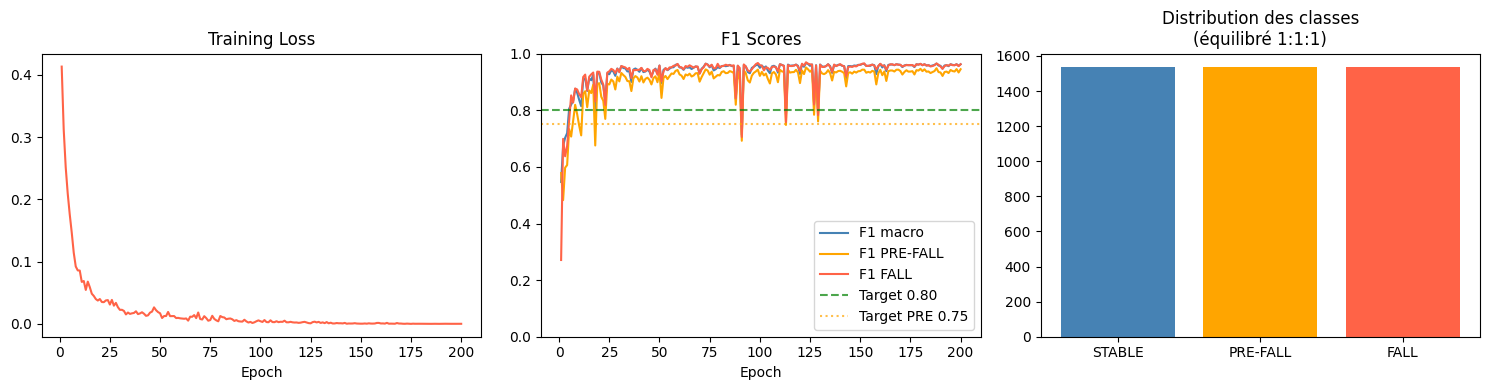


🎯 Résumé final :
   Best epoch  : 123
   F1 macro    : 0.9673
   Accuracy    : 0.9674
   Modèle      : /content/dgnn_best.pth
   Courbes     : /content/dgnn_training.png


In [25]:
# ============================================================
# CELL 13 (FINAL v3) — Entraînement DGNN — dataset équilibré
# ============================================================
import torch, torch.nn as nn, numpy as np
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.metrics import classification_report, f1_score, accuracy_score
from collections import Counter
from pathlib import Path
import matplotlib.pyplot as plt

SAVE_PATH = Path("/content/urfd_keypoints")
device    = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"✅ Device : {device}")

# ── Chargement données ───────────────────────────────────────
X = np.load(SAVE_PATH / "X_urfd.npy")
Y = np.load(SAVE_PATH / "Y_urfd.npy")
counts = Counter(Y.tolist())
total  = len(Y)
print(f"Dataset : {X.shape} | {counts}")
print(f"  STABLE   (0) : {counts[0]:6d} ({100*counts[0]/total:.1f}%)")
print(f"  PRE-FALL (1) : {counts[1]:6d} ({100*counts[1]/total:.1f}%)")
print(f"  FALL     (2) : {counts[2]:6d} ({100*counts[2]/total:.1f}%)")

# ── Focal Loss ───────────────────────────────────────────────
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, weight=None):
        super().__init__()
        self.gamma  = gamma
        self.weight = weight
    def forward(self, logits, targets):
        ce  = F.cross_entropy(logits, targets,
                              weight=self.weight, reduction='none')
        pt  = torch.exp(-ce)
        return (((1 - pt) ** self.gamma) * ce).mean()

# ── Class weights égaux — dataset déjà équilibré 1:1:1 ──────
weights = torch.tensor([1.0, 1.0, 1.0],
                       dtype=torch.float32).to(device)
print(f"\nClass weights : {weights.cpu().numpy()} (égaux — dataset équilibré)")

# ── Dataset ──────────────────────────────────────────────────
class URFDDataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.Y = torch.tensor(Y, dtype=torch.long)
    def __len__(self):        return len(self.X)
    def __getitem__(self, i): return self.X[i], self.Y[i]

torch.manual_seed(42)
dataset  = URFDDataset(X, Y)
n_val    = int(0.2 * len(dataset))
n_train  = len(dataset) - n_val
train_ds, val_ds = random_split(
    dataset, [n_train, n_val],
    generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_ds, batch_size=64,
                          shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=64,
                          shuffle=False, num_workers=2)
print(f"Train: {n_train} | Val: {n_val}")

# ── Modèle from scratch ──────────────────────────────────────
model_dgnn = DGNNClassifier(T=30, n_classes=3, hidden=64).to(device)
criterion  = FocalLoss(gamma=2.0, weight=weights)
optimizer  = torch.optim.AdamW(
    model_dgnn.parameters(), lr=5e-4, weight_decay=2e-4)

# Scheduler stable — descente douce sans resets
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=200, eta_min=1e-6)

EPOCHS  = 200
best_f1 = 0.0
history = []

print(f"\n🚀 Entraînement : {EPOCHS} epochs")
print(f"   Scheduler  : CosineAnnealingLR (5e-4 → 1e-6)")
print(f"   Focal Loss : gamma=2.0")
print(f"   Weights    : 1.0 / 1.0 / 1.0 (équilibré)\n")

for epoch in range(1, EPOCHS + 1):

    # ── Train ────────────────────────────────────────────────
    model_dgnn.train()
    total_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model_dgnn(xb), yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_dgnn.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
    scheduler.step()

    # ── Validation ───────────────────────────────────────────
    model_dgnn.eval()
    all_logits, all_true = [], []
    with torch.no_grad():
        for xb, yb in val_loader:
            all_logits.append(model_dgnn(xb.to(device)).cpu())
            all_true.extend(yb.tolist())

    all_logits = torch.cat(all_logits)
    all_probs  = torch.softmax(all_logits, dim=1).numpy()
    all_true   = np.array(all_true)
    preds      = all_logits.argmax(dim=1).numpy()

    val_acc = accuracy_score(all_true, preds)
    val_f1  = f1_score(all_true, preds, average='macro', zero_division=0)
    f1_all  = f1_score(all_true, preds, average=None,    zero_division=0)
    fall_f1 = f1_all[2] if len(f1_all) > 2 else 0.0
    pre_f1  = f1_all[1] if len(f1_all) > 1 else 0.0

    # ── Sauvegarde si meilleur F1 ─────────────────────────────
    star = ''
    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save({
            'model_state': model_dgnn.state_dict(),
            'epoch':       epoch,
            'val_f1':      val_f1,
            'val_acc':     val_acc,
        }, '/content/dgnn_best.pth')
        star = '⭐'

    history.append({
        'epoch':   epoch,
        'loss':    total_loss / len(train_loader),
        'val_acc': val_acc,
        'val_f1':  val_f1,
        'fall_f1': fall_f1,
        'pre_f1':  pre_f1
    })

    if epoch % 10 == 0 or epoch == 1:
        lr = optimizer.param_groups[0]['lr']
        print(f"Ep {epoch:03d} | "
              f"Loss: {total_loss/len(train_loader):.4f} | "
              f"Acc: {val_acc:.3f} | "
              f"F1macro: {val_f1:.3f} | "
              f"F1_pre: {pre_f1:.3f} | "
              f"F1_fall: {fall_f1:.3f} | "
              f"LR: {lr:.1e} {star}")

# ── Chargement meilleur modèle ───────────────────────────────
print("\n" + "="*55)
ckpt = torch.load('/content/dgnn_best.pth')
model_dgnn.load_state_dict(ckpt['model_state'])
print(f"✅ Best model : epoch {ckpt['epoch']} | F1={ckpt['val_f1']:.4f}")

# ── Threshold sweep ──────────────────────────────────────────
model_dgnn.eval()
all_logits, all_true = [], []
with torch.no_grad():
    for xb, yb in val_loader:
        all_logits.append(model_dgnn(xb.to(device)).cpu())
        all_true.extend(yb.tolist())

all_logits = torch.cat(all_logits)
all_probs  = torch.softmax(all_logits, dim=1).numpy()
all_true   = np.array(all_true)

print("\n  Threshold sweep :")
best_thresh, best_fall_f1 = 0.3, 0.0
for thresh in np.arange(0.10, 0.60, 0.05):
    preds_t = all_logits.argmax(dim=1).numpy().copy()
    preds_t[all_probs[:, 2] > thresh] = 2
    f1_t    = f1_score(all_true, preds_t, average=None,    zero_division=0)
    f1_mac  = f1_score(all_true, preds_t, average='macro', zero_division=0)
    f1_fall = f1_t[2] if len(f1_t) > 2 else 0
    print(f"    thresh={thresh:.2f} | "
          f"F1_fall={f1_fall:.3f} | "
          f"F1_macro={f1_mac:.3f}")
    if f1_fall > best_fall_f1:
        best_fall_f1, best_thresh = f1_fall, thresh

print(f"\n✅ Best threshold : {best_thresh:.2f} → "
      f"F1_fall={best_fall_f1:.3f}")

# ── Rapport final ────────────────────────────────────────────
preds_final = all_logits.argmax(dim=1).numpy().copy()
preds_final[all_probs[:, 2] > best_thresh] = 2

print("\n📊 RAPPORT FINAL :")
print("="*55)
print(classification_report(all_true, preds_final,
      target_names=['STABLE', 'PRE-FALL', 'FALL']))

# ── Comparaison historique ────────────────────────────────────
f1c = f1_score(all_true, preds_final, average=None, zero_division=0)
mac = f1_score(all_true, preds_final, average='macro', zero_division=0)
print("📊 PROGRESSION HISTORIQUE :")
print(f"  {'':12} {'V1':>7} {'V2':>7} {'V3':>7} {'V4':>7} {'Maintenant':>12}")
print(f"  {'STABLE':12} {'0.91':>7} {'0.94':>7} {'0.96':>7} "
      f"{'0.99':>7} {f1c[0]:.2f}{'>':>11}")
print(f"  {'PRE-FALL':12} {'0.25':>7} {'0.71':>7} {'0.75':>7} "
      f"{'0.76':>7} {f1c[1]:.2f}{'>':>11}")
print(f"  {'FALL':12} {'0.00':>7} {'0.86':>7} {'0.84':>7} "
      f"{'0.86':>7} {f1c[2]:.2f}{'>':>11}")
print(f"  {'F1 macro':12} {'0.56':>7} {'0.84':>7} {'0.85':>7} "
      f"{'0.87':>7} {mac:.2f}{'>':>11}")
print(f"  {'Accuracy':12} {'0.79':>7} {'0.88':>7} {'0.90':>7} "
      f"{'0.95':>7} {ckpt['val_acc']:.2f}{'>':>11}")

# ── Courbes ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
epochs_ = [h['epoch']   for h in history]
loss_   = [h['loss']    for h in history]
f1mac_  = [h['val_f1']  for h in history]
f1fall_ = [h['fall_f1'] for h in history]
f1pre_  = [h['pre_f1']  for h in history]

axes[0].plot(epochs_, loss_, color='tomato')
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')

axes[1].plot(epochs_, f1mac_,  color='steelblue', label='F1 macro')
axes[1].plot(epochs_, f1pre_,  color='orange',    label='F1 PRE-FALL')
axes[1].plot(epochs_, f1fall_, color='tomato',    label='F1 FALL')
axes[1].axhline(y=0.80, color='green',
                linestyle='--', alpha=0.7, label='Target 0.80')
axes[1].axhline(y=0.75, color='orange',
                linestyle=':',  alpha=0.7, label='Target PRE 0.75')
axes[1].legend()
axes[1].set_title('F1 Scores')
axes[1].set_xlabel('Epoch')
axes[1].set_ylim(0, 1)

axes[2].bar(['STABLE', 'PRE-FALL', 'FALL'],
            [counts[0], counts[1], counts[2]],
            color=['steelblue', 'orange', 'tomato'])
axes[2].set_title('Distribution des classes\n(équilibré 1:1:1)')

plt.tight_layout()
plt.savefig('/content/dgnn_training.png', dpi=200)
plt.show()

print(f"\n🎯 Résumé final :")
print(f"   Best epoch  : {ckpt['epoch']}")
print(f"   F1 macro    : {ckpt['val_f1']:.4f}")
print(f"   Accuracy    : {ckpt['val_acc']:.4f}")
print(f"   Modèle      : /content/dgnn_best.pth")
print(f"   Courbes     : /content/dgnn_training.png")